In [46]:
import numpy as np
import scipy.signal as signal
import scipy.io.wavfile as wavfile
from scipy.fft import rfft, rfftfreq, irfft
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import os


In [47]:
save_path = "./audio"


In [48]:
class AudioTransferFunction:
    """
    Generate and apply transfer functions for audio system characterization.

    This class computes the frequency-domain transfer function H(f) = A(f) / R(f)
    where R is the reference signal and A is the acquired signal after passing
    through the system.
    """

    def __init__(self, reference_path, acquired_path):
        """
        Load and prepare audio files for transfer function computation.

        Args:
            reference_path: Path to reference audio file
            acquired_path: Path to acquired audio file
        """
        # Load audio files
        self.ref_sr, self.reference = wavfile.read(reference_path)
        self.acq_sr, self.acquired = wavfile.read(acquired_path)
        
        # Ensure both files have the same sample rate
        if self.ref_sr != self.acq_sr:
            raise ValueError(f"Sample rates don't match: {self.ref_sr} vs {self.acq_sr}")
        
        self.sample_rate = self.ref_sr
        
        # Convert to mono if stereo (average channels)
        if len(self.reference.shape) > 1:
            self.reference = np.mean(self.reference, axis=1)
        if len(self.acquired.shape) > 1:
            self.acquired = np.mean(self.acquired, axis=1)
        
        # Handle different audio formats (int16, int32, float32)
        if self.reference.dtype == np.float32 or self.reference.dtype == np.float64:
            self.reference = self.reference.astype(np.float64)
        else:
            # Convert integer formats to float [-1, 1]
            self.reference = self.reference.astype(np.float64) / np.iinfo(self.reference.dtype).max
        
        if self.acquired.dtype == np.float32 or self.acquired.dtype == np.float64:
            self.acquired = self.acquired.astype(np.float64)
        else:
            self.acquired = self.acquired.astype(np.float64) / np.iinfo(self.acquired.dtype).max
        
        # Align signals to account for time delays in acquisition system
        self._align_signals()
        
        # Make signals equal length (required for frequency domain division)
        min_length = min(len(self.reference), len(self.acquired))
        self.reference = self.reference[:min_length]
        self.acquired = self.acquired[:min_length]
        
        # Store original length for later use
        self.original_length = len(self.reference)
        
        self.transfer_function = None
        self.frequencies = None
        
    def _align_signals(self):
        """
        Align acquired signal to reference using cross-correlation.
        
        Cross-correlation identifies the time lag that maximizes similarity
        between signals, compensating for propagation delays in the system.
        """
        # Compute cross-correlation
        correlation = signal.correlate(self.acquired, self.reference, mode='full')
        
        # Find the lag with maximum correlation
        lag = np.argmax(correlation) - (len(self.reference) - 1)
        
        print(f"Signal alignment: {lag} samples ({lag/self.sample_rate*1000:.2f} ms)")
        
        # Shift acquired signal to align with reference
        if lag > 0:
            self.acquired = self.acquired[lag:]
            self.reference = self.reference[:len(self.acquired)]
        elif lag < 0:
            self.reference = self.reference[-lag:]
            self.acquired = self.acquired[:len(self.reference)]
    
    def compute_transfer_function(self, smoothing_window=None):
        """
        Compute the frequency-domain transfer function H(f) = A(f) / R(f).
        
        Args:
            smoothing_window: Optional window size for smoothing the transfer function.
                            Helps reduce noise and measurement artifacts.
                            Recommended: 1-5% of frequency bins (e.g., 50-200)
        
        The transfer function characterizes how the system modifies each frequency.
        """
        # Compute FFT (using real FFT for efficiency with real signals)
        ref_fft = rfft(self.reference)
        acq_fft = rfft(self.acquired)
        
        # Compute frequency array
        self.frequencies = rfftfreq(len(self.reference), 1/self.sample_rate)
        
        # Compute transfer function: H(f) = A(f) / R(f)
        epsilon = 1e-10
        self.transfer_function = acq_fft / (ref_fft + epsilon)

        # Optional smoothing to reduce noise and measurement artifacts
        if smoothing_window:
            window = np.ones(smoothing_window) / smoothing_window
            magnitude = np.abs(self.transfer_function)
            phase = np.angle(self.transfer_function)

            magnitude_smooth = np.convolve(magnitude, window, mode='same')
            phase_smooth = np.convolve(phase, window, mode='same')
            
            self.transfer_function = magnitude_smooth * np.exp(1j * phase_smooth)
        
        print(f"Transfer function computed: {len(self.transfer_function)} frequency bins")
        return self.transfer_function, self.frequencies
    
    def apply_transfer_function(self, input_audio_path, output_path, output_format='float32'):
        """
        Apply the learned transfer function to a new audio file.
        
        This simulates how the acquisition system would modify the input audio.
        
        Args:
            input_audio_path: Path to input audio file
            output_path: Path to save processed audio
            output_format: Output format - 'float32' (for GStreamer compatibility) or 'int16'
        """
        if self.transfer_function is None:
            raise ValueError("Transfer function not computed. Call compute_transfer_function() first.")
        
        # Load input audio
        sr, audio = wavfile.read(input_audio_path)
        
        if sr != self.sample_rate:
            raise ValueError(f"Sample rate mismatch: {sr} vs {self.sample_rate}")
        
        # Store original length to ensure output matches input exactly
        original_length = len(audio)
        
        # Convert to mono and normalize
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)

        # Handle different audio formats
        if audio.dtype == np.float32 or audio.dtype == np.float64:
            audio = audio.astype(np.float64)
        else:
            audio = audio.astype(np.float64) / np.iinfo(audio.dtype).max

        # Apply transfer function in frequency domain
        audio_fft = rfft(audio)

        # Interpolate transfer function if audio length differs
        if len(audio_fft) != len(self.transfer_function):
            print(f"Interpolating transfer function: {len(self.transfer_function)} -> {len(audio_fft)} bins")
            
            f_orig = np.linspace(0, 1, len(self.transfer_function))
            f_target = np.linspace(0, 1, len(audio_fft))
            
            interp_real = interp1d(f_orig, np.real(self.transfer_function), 
                                  kind='linear', fill_value='extrapolate')
            interp_imag = interp1d(f_orig, np.imag(self.transfer_function), 
                                  kind='linear', fill_value='extrapolate')
            tf = interp_real(f_target) + 1j * interp_imag(f_target)
        else:
            tf = self.transfer_function

        # Apply transfer function: Y(f) = X(f) * H(f)
        output_fft = audio_fft * tf

        # Convert back to time domain - CRITICAL: specify original length explicitly
        output_audio = irfft(output_fft, n=original_length)

        # Verify length matches
        assert len(output_audio) == original_length, \
            f"Length mismatch! Got {len(output_audio)}, expected {original_length}"

        # Normalize to prevent clipping
        max_val = np.max(np.abs(output_audio))
        if max_val > 0:
            output_audio = output_audio / max_val * 0.95

        # Save in requested format
        if output_format == 'float32':
            output_audio = output_audio.astype(np.float32)
        else:
            output_audio = (output_audio * 32767).astype(np.int16)
        
        wavfile.write(output_path, self.sample_rate, output_audio)
        print(f"Processed audio saved to {output_path}")
        print(f"  Format: {output_format}, Length: {len(output_audio)} samples ({len(output_audio)/self.sample_rate:.3f} seconds)")
        
        return output_audio

    def plot_transfer_function(self):
        """
        Visualize the transfer function's magnitude and phase response.
        
        Magnitude shows frequency-dependent gain/attenuation.
        Phase shows frequency-dependent time delays.
        """
        if self.transfer_function is None:
            raise ValueError("Transfer function not computed. Call compute_transfer_function() first.")
        
        magnitude_db = 20 * np.log10(np.abs(self.transfer_function) + 1e-10)
        phase_deg = np.angle(self.transfer_function) * 180 / np.pi
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        # Magnitude response
        ax1.semilogx(self.frequencies[1:], magnitude_db[1:])
        ax1.set_xlabel('Frequency (Hz)')
        ax1.set_ylabel('Magnitude (dB)')
        ax1.set_title('Transfer Function Magnitude Response')
        ax1.grid(True, which='both', alpha=0.3)
        
        # Phase response
        ax2.semilogx(self.frequencies[1:], phase_deg[1:])
        ax2.set_xlabel('Frequency (Hz)')
        ax2.set_ylabel('Phase (degrees)')
        ax2.set_title('Transfer Function Phase Response')
        ax2.grid(True, which='both', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('transfer_function.png', dpi=150)
        print("Transfer function plot saved to transfer_function.png")
        plt.show()


In [55]:
def compare_audio_files(file1_path, file2_path, align=True):
    """
    Compare two audio files and compute various difference metrics.
    
    Args:
        file1_path: Path to first WAV file
        file2_path: Path to second WAV file
        align: Whether to align signals using cross-correlation (default: True)
    
    Returns:
        Dictionary containing various comparison metrics
    """
    
    # Load audio files
    sr1, audio1 = wavfile.read(file1_path)
    sr2, audio2 = wavfile.read(file2_path)
    
    # Check sample rates match
    if sr1 != sr2:
        print(f"Warning: Sample rates don't match ({sr1} vs {sr2})")
        return None
    
    sr = sr1
    
    # Convert to mono if stereo
    if len(audio1.shape) > 1:
        audio1 = np.mean(audio1, axis=1)
    if len(audio2.shape) > 1:
        audio2 = np.mean(audio2, axis=1)
    
    # Convert to float for consistent processing
    if audio1.dtype in [np.float32, np.float64]:
        audio1 = audio1.astype(np.float64)
    else:
        audio1 = audio1.astype(np.float64) / np.iinfo(audio1.dtype).max
    
    if audio2.dtype in [np.float32, np.float64]:
        audio2 = audio2.astype(np.float64)
    else:
        audio2 = audio2.astype(np.float64) / np.iinfo(audio2.dtype).max
    
    print(f"\nFile 1: {len(audio1)} samples ({len(audio1)/sr:.3f} seconds)")
    print(f"File 2: {len(audio2)} samples ({len(audio2)/sr:.3f} seconds)")
    
    # Align signals if requested
    if align:
        correlation = signal.correlate(audio2, audio1, mode='full')
        lag = np.argmax(correlation) - (len(audio1) - 1)
        print(f"Time alignment: {lag} samples ({lag/sr*1000:.2f} ms)")
        
        if lag > 0:
            audio2 = audio2[lag:]
            audio1 = audio1[:len(audio2)]
        elif lag < 0:
            audio1 = audio1[-lag:]
            audio2 = audio2[:len(audio1)]
    
    # Make same length
    min_length = min(len(audio1), len(audio2))
    audio1 = audio1[:min_length]
    audio2 = audio2[:min_length]
    
    print(f"Comparing {min_length} samples ({min_length/sr:.3f} seconds)")
    
    # Compute difference
    difference = audio2 - audio1
    
    # Calculate various metrics
    metrics = {}
    
    # Mean Absolute Error (MAE)
    metrics['mae'] = np.mean(np.abs(difference))
    
    # Root Mean Square Error (RMSE)
    metrics['rmse'] = np.sqrt(np.mean(difference**2))
    
    # Peak difference
    metrics['peak_diff'] = np.max(np.abs(difference))
    
    # Signal-to-Noise Ratio (SNR)
    signal_power = np.mean(audio1**2)
    noise_power = np.mean(difference**2)
    if noise_power > 0:
        metrics['snr_db'] = 10 * np.log10(signal_power / noise_power)
    else:
        metrics['snr_db'] = np.inf
    
    # Correlation coefficient
    metrics['correlation'] = np.corrcoef(audio1, audio2)[0, 1]
    
    # RMS levels of each signal
    metrics['rms1'] = np.sqrt(np.mean(audio1**2))
    metrics['rms2'] = np.sqrt(np.mean(audio2**2))
    metrics['rms_ratio_db'] = 20 * np.log10(metrics['rms2'] / (metrics['rms1'] + 1e-10))
    
    # Percentage difference
    signal_range = max(np.max(np.abs(audio1)), np.max(np.abs(audio2)))
    metrics['percent_diff'] = (metrics['rmse'] / signal_range) * 100
    
    # Print results
    print("\n" + "="*60)
    print("COMPARISON METRICS")
    print("="*60)
    print(f"Mean Absolute Error (MAE):        {metrics['mae']:.6f}")
    print(f"Root Mean Square Error (RMSE):    {metrics['rmse']:.6f}")
    print(f"Peak Difference:                  {metrics['peak_diff']:.6f}")
    print(f"Percent Difference:               {metrics['percent_diff']:.2f}%")
    print(f"Signal-to-Noise Ratio (SNR):      {metrics['snr_db']:.2f} dB")
    print(f"Correlation Coefficient:          {metrics['correlation']:.6f}")
    print(f"\nRMS Level File 1:                 {metrics['rms1']:.6f}")
    print(f"RMS Level File 2:                 {metrics['rms2']:.6f}")
    print(f"RMS Ratio (File2/File1):          {metrics['rms_ratio_db']:.2f} dB")
    print("="*60)
    
    # Plot comparison
    plot_comparison(audio1, audio2, difference, sr, metrics)
    
    return metrics, audio1, audio2, difference, sr


In [56]:
def plot_comparison(audio1, audio2, difference, sr, metrics):
    """
    Create visualizations comparing the two audio signals.
    """
    time = np.arange(len(audio1)) / sr
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    
    # Plot 1: Both waveforms
    axes[0].plot(time, audio1, alpha=0.7, label='File 1', linewidth=0.5)
    axes[0].plot(time, audio2, alpha=0.7, label='File 2', linewidth=0.5)
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title('Waveform Comparison')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Difference signal
    axes[1].plot(time, difference, color='red', linewidth=0.5)
    axes[1].set_ylabel('Amplitude')
    axes[1].set_title(f'Difference Signal (RMSE: {metrics["rmse"]:.6f})')
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Frequency spectrum comparison
    freq1, psd1 = signal.welch(audio1, sr, nperseg=2048)
    freq2, psd2 = signal.welch(audio2, sr, nperseg=2048)
    
    axes[2].semilogy(freq1, psd1, alpha=0.7, label='File 1')
    axes[2].semilogy(freq2, psd2, alpha=0.7, label='File 2')
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Power Spectral Density')
    axes[2].set_title('Frequency Spectrum Comparison')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # Plot 4: Difference histogram
    axes[3].hist(difference, bins=100, color='red', alpha=0.7, edgecolor='black')
    axes[3].set_xlabel('Difference Value')
    axes[3].set_ylabel('Count')
    axes[3].set_title(f'Difference Distribution (Mean: {np.mean(difference):.6f}, Std: {np.std(difference):.6f})')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('audio_comparison.png', dpi=150)
    print("\nComparison plot saved to 'audio_comparison.png'")
    plt.show()


AUDIO TRANSFER FUNCTION ANALYSIS

1. Loading and preparing audio files...
   Reference: 400000 samples
   Acquired:  400000 samples

2. Initializing transfer function analyzer...
Signal alignment: 1045 samples (65.31 ms)

3. Computing transfer function...
Transfer function computed: 199478 frequency bins

4. Plotting transfer function...


/tmp/ipykernel_804/1586036317.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  acq_sr, acquired = wavfile.read(save_path + '/acquired.wav')


Transfer function plot saved to transfer_function.png


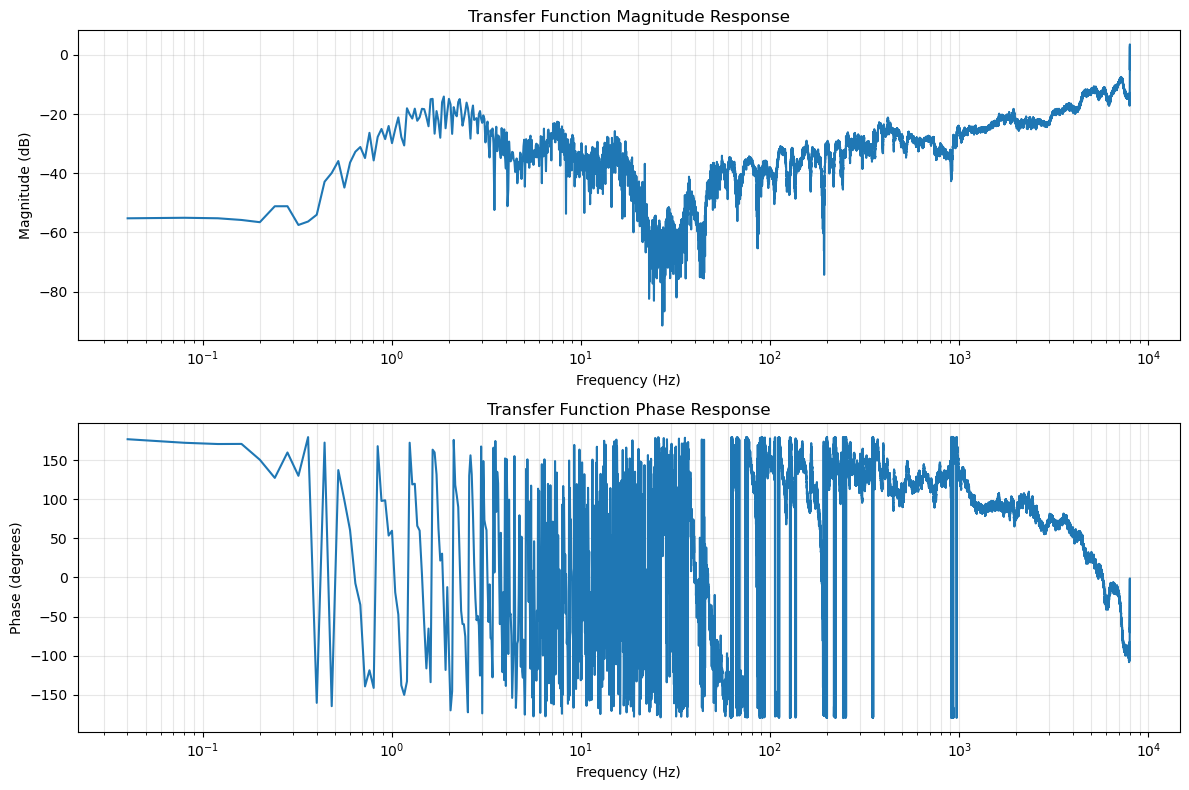


5. Applying transfer function to new audio...
Interpolating transfer function: 199478 -> 200001 bins
Processed audio saved to ./audio/output_processed.wav
  Format: float32, Length: 400000 samples (25.000 seconds)

6. Verifying output...
   Input length:  400000 samples
   Output length: 400000 samples
   Match: True

7. Comparing processed output with acquired signal...

File 1: 400000 samples (25.000 seconds)
File 2: 400000 samples (25.000 seconds)
Time alignment: 1045 samples (65.31 ms)
Comparing 398955 samples (24.935 seconds)

COMPARISON METRICS
Mean Absolute Error (MAE):        0.050617
Root Mean Square Error (RMSE):    0.094721
Peak Difference:                  0.596228
Percent Difference:               9.97%
Signal-to-Noise Ratio (SNR):      4.05 dB
Correlation Coefficient:          0.999896

RMS Level File 1:                 0.151015
RMS Level File 2:                 0.056303
RMS Ratio (File2/File1):          -8.57 dB

Comparison plot saved to 'audio_comparison.png'


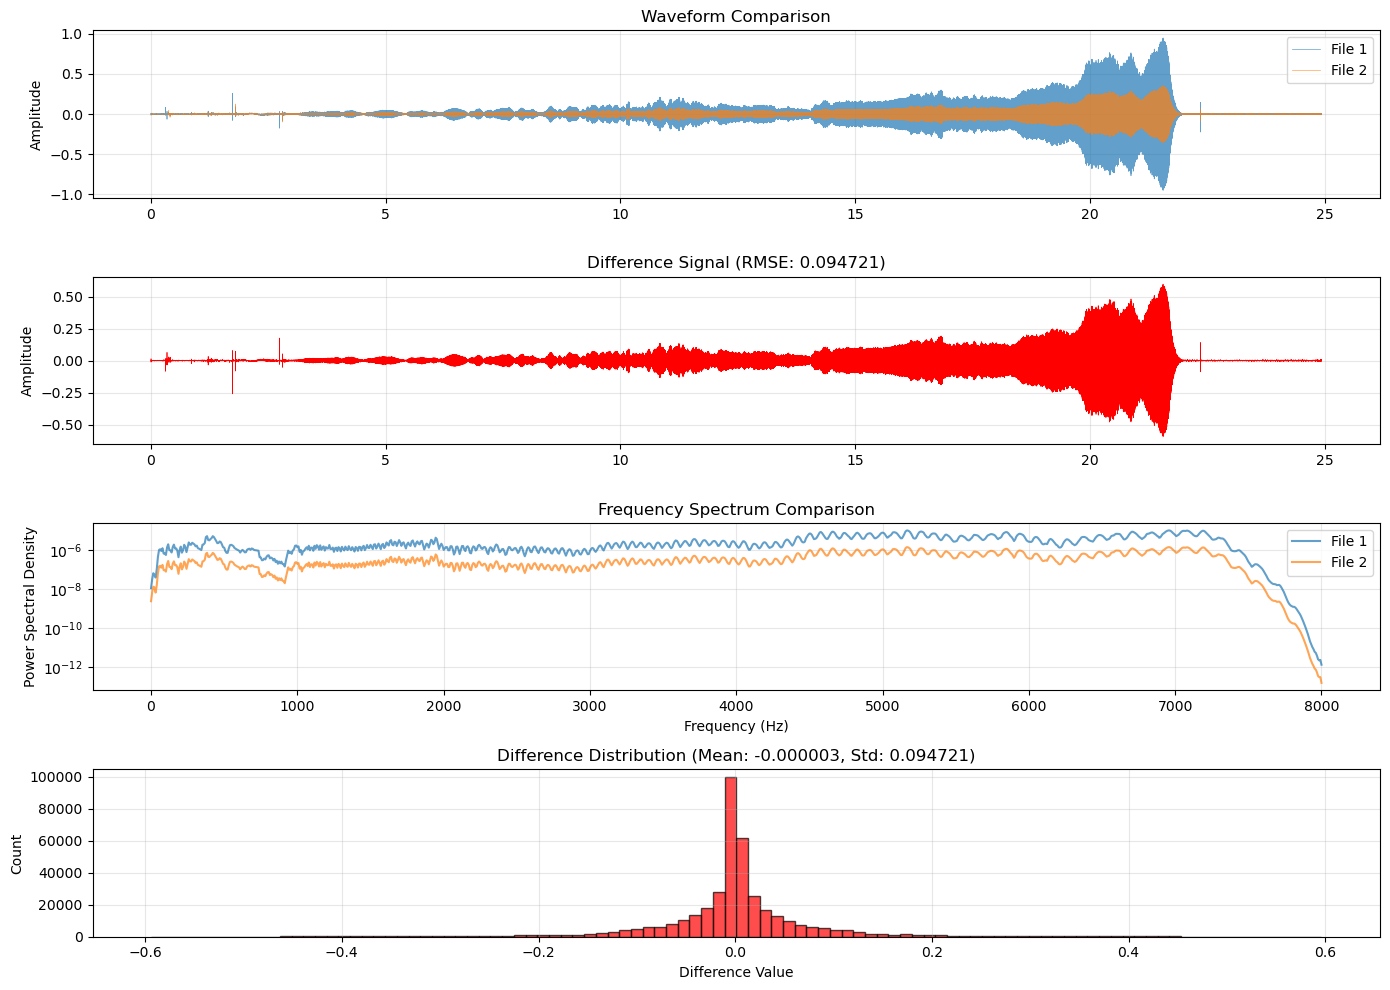


ANALYSIS COMPLETE!
Sample rate: 16000 Hz
Transfer function frequency bins: 199478


In [59]:
print("="*60)
print("AUDIO TRANSFER FUNCTION ANALYSIS")
print("="*60)

# Load and prepare reference and acquired files
print("\n1. Loading and preparing audio files...")
ref_sr, reference = wavfile.read(save_path + '/reference.wav')
acq_sr, acquired = wavfile.read(save_path + '/acquired.wav')

# Trim to same length
cutting = min(len(acquired), len(reference))
reference = reference[:cutting]
acquired = acquired[:cutting]

print(f"   Reference: {len(reference)} samples")
print(f"   Acquired:  {len(acquired)} samples")

# Save trimmed versions
wavfile.write(save_path + '/reference.2.wav', ref_sr, reference)
wavfile.write(save_path + '/acquired.2.wav', ref_sr, acquired)

# Initialize transfer function analyzer
print("\n2. Initializing transfer function analyzer...")
tf_analyzer = AudioTransferFunction(save_path + '/reference.2.wav', 
                                   save_path + '/acquired.2.wav')

# Compute transfer function
print("\n3. Computing transfer function...")
transfer_func, freqs = tf_analyzer.compute_transfer_function(smoothing_window=None)

# Visualize
print("\n4. Plotting transfer function...")
tf_analyzer.plot_transfer_function()

# Apply to new audio
print("\n5. Applying transfer function to new audio...")
tf_analyzer.apply_transfer_function(save_path + '/reference.2.wav', 
                                   save_path + '/output_processed.wav', 
                                   output_format='float32')

# Verify output file length
print("\n6. Verifying output...")
sr_output, output_verify = wavfile.read(save_path + '/output_processed.wav')
sr_input, input_verify = wavfile.read(save_path + '/reference.2.wav')
print(f"   Input length:  {len(input_verify)} samples")
print(f"   Output length: {len(output_verify)} samples")
print(f"   Match: {len(input_verify) == len(output_verify)}")

# Compare processed output with acquired signal
print("\n7. Comparing processed output with acquired signal...")
file1 = save_path + '/output_processed.wav'
file2 = save_path + '/acquired.2.wav'

metrics, audio1, audio2, difference, sr = compare_audio_files(file1, file2, align=True)

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print(f"Sample rate: {tf_analyzer.sample_rate} Hz")
print(f"Transfer function frequency bins: {len(transfer_func)}")


Average TF gain: -16.32 dB
Average gain 0-200Hz: -37.03 dB
Average gain 200-3000Hz: -24.54 dB
Average gain 3000+ Hz: -13.53 dB
DC gain: -53.23 dB


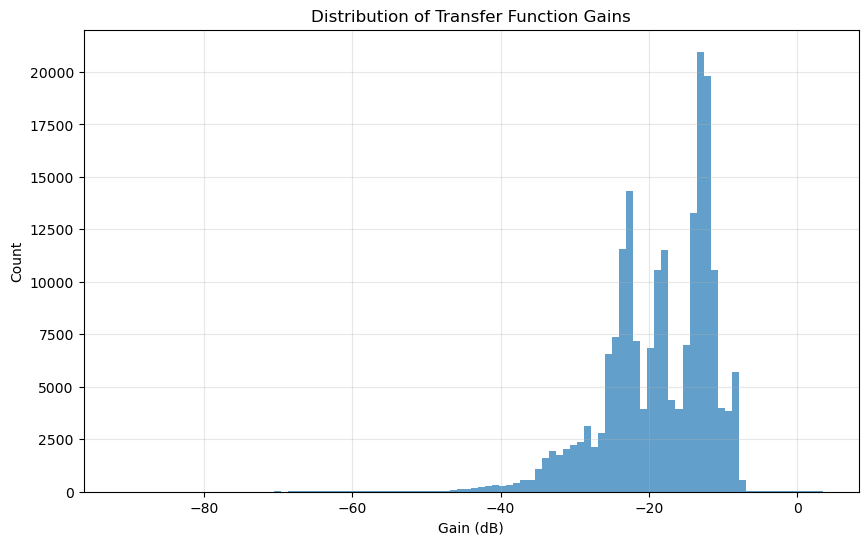

In [60]:
def diagnose_transfer_function(tf_analyzer):
    """Run diagnostics on the transfer function."""
    
    # 1. Check overall gain
    avg_magnitude = np.mean(np.abs(tf_analyzer.transfer_function))
    avg_gain_db = 20 * np.log10(avg_magnitude)
    print(f"Average TF gain: {avg_gain_db:.2f} dB")
    
    # 2. Check frequency bands
    freqs = tf_analyzer.frequencies
    tf_mag = np.abs(tf_analyzer.transfer_function)
    
    # Low frequencies (0-200 Hz)
    low_mask = freqs <= 200
    avg_low = np.mean(tf_mag[low_mask]) if np.any(low_mask) else 0
    print(f"Average gain 0-200Hz: {20*np.log10(avg_low):.2f} dB")
    
    # Mid frequencies (200-3000 Hz)
    mid_mask = (freqs > 200) & (freqs <= 3000)
    avg_mid = np.mean(tf_mag[mid_mask]) if np.any(mid_mask) else 0
    print(f"Average gain 200-3000Hz: {20*np.log10(avg_mid):.2f} dB")
    
    # High frequencies (3000+ Hz)
    high_mask = freqs > 3000
    avg_high = np.mean(tf_mag[high_mask]) if np.any(high_mask) else 0
    print(f"Average gain 3000+ Hz: {20*np.log10(avg_high):.2f} dB")
    
    # 3. Check if there's DC offset
    dc_gain = tf_mag[0] if len(tf_mag) > 0 else 0
    print(f"DC gain: {20*np.log10(dc_gain):.2f} dB")
    
    # 4. Plot histogram of TF magnitudes
    plt.figure(figsize=(10, 6))
    plt.hist(20*np.log10(tf_mag[1:]), bins=100, alpha=0.7)
    plt.xlabel('Gain (dB)')
    plt.ylabel('Count')
    plt.title('Distribution of Transfer Function Gains')
    plt.grid(True, alpha=0.3)
    plt.show()

# Run diagnostics
diagnose_transfer_function(tf_analyzer)
